<img src="../Decorative-Elements/Section-06/ADL-S06-Image-01.png">
<img src="../Decorative-Elements/Section-06/ADL-S06-Image-02.png">

<p style="display: flex; justify-content: space-between;">
  <a href="../05-Applications/05-Black-Hole-Formation.ipynb" target="_blank">Previous</a>
  <a href="../06-More-Applications/02-Collision-and-Impact-Theory.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-06/ADL-S06-Image-03.png">

In [1]:
import rebound
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# create simulation (dummy solar system)
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Add Sun
sim.add(m=1.0)

# Add Earth (circular orbit)
sim.add(m=3e-6, a=1.0)

# Add spacecraft (dummy object near Earth)
sim.add(m=0, a=1.05, e=0.1)

sim.move_to_com()

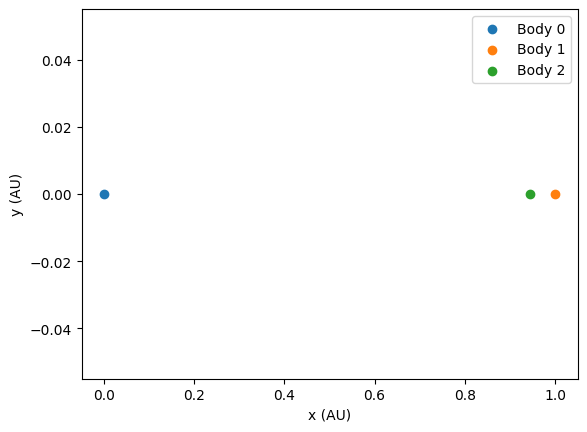

In [3]:
# basic orbit visualisation
fig, ax = plt.subplots()

for i, particle in enumerate(sim.particles):
    ax.scatter(particle.x, particle.y, label=f'Body {i}')

ax.set_xlabel("x (AU)")
ax.set_ylabel("y (AU)")
ax.legend()
plt.show()

In [4]:
# simulate trajectory over the time
times = np.linspace(0, 2, 200)

x_vals = []
y_vals = []

for t in times:
    sim.integrate(t)
    spacecraft = sim.particles[2]
    x_vals.append(spacecraft.x)
    y_vals.append(spacecraft.y)

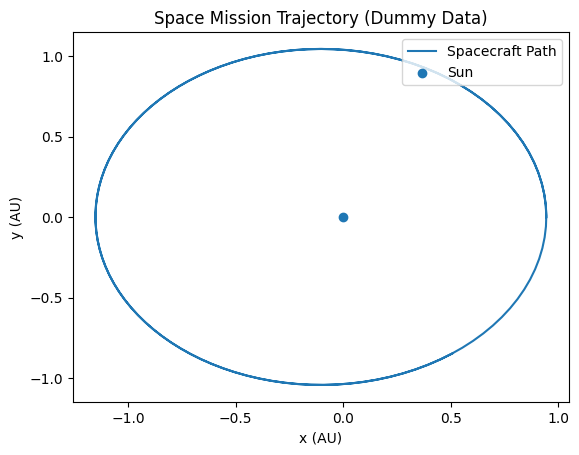

In [5]:
# plot space-craft trajectory
plt.plot(x_vals, y_vals, label="Spacecraft Path")
plt.scatter(0, 0, label="Sun")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.legend()
plt.legend(loc = "upper right")
plt.title("Space Mission Trajectory (Dummy Data)")
plt.show()

In [6]:
# Reset simulation
# Operation: Change Initial Velocity (Trajectory Control)
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

sim.add(m=1.0)          # Sun
sim.add(m=3e-6, a=1.0) # Earth

# Spacecraft with modified velocity
sim.add(m=0, a=1.05, e=0.3)

sim.move_to_com()

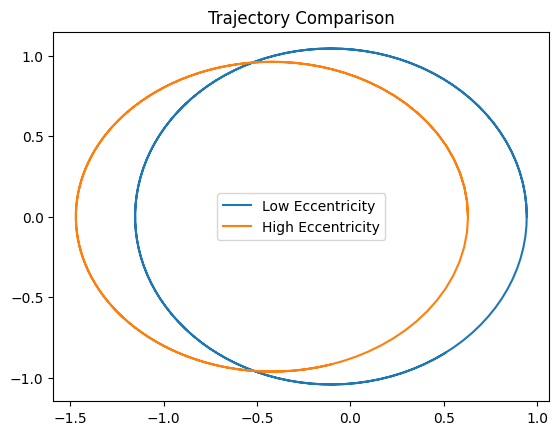

In [7]:
# compare two trajectories over time
def simulate_trajectory(ecc):
    sim = rebound.Simulation()
    sim.units = ('AU', 'yr', 'Msun')
    
    sim.add(m=1.0)
    sim.add(m=3e-6, a=1.0)
    sim.add(m=0, a=1.05, e=ecc)
    
    sim.move_to_com()
    
    x, y = [], []
    times = np.linspace(0, 2, 200)
    
    for t in times:
        sim.integrate(t)
        p = sim.particles[2]
        x.append(p.x)
        y.append(p.y)
    
    return x, y

x1, y1 = simulate_trajectory(0.1)
x2, y2 = simulate_trajectory(0.4)

plt.plot(x1, y1, label="Low Eccentricity")
plt.plot(x2, y2, label="High Eccentricity")
plt.legend()
plt.title("Trajectory Comparison")
plt.show()

In [8]:
# gravity assist 
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Sun, Earth, Jupiter
sim.add(m=1.0)            # Sun
sim.add(m=3e-6, a=1.0)    # Earth
sim.add(m=0.001, a=5.2)   # Jupiter (for gravity assist)

# Spacecraft aimed toward Jupiter
sim.add(m=0, a=1.2, e=0.5)

sim.move_to_com()

In [9]:
# simulate gravity assist path
times = np.linspace(0, 10, 500)

x_vals = []
y_vals = []

for t in times:
    sim.integrate(t)
    sc = sim.particles[3]
    x_vals.append(sc.x)
    y_vals.append(sc.y)

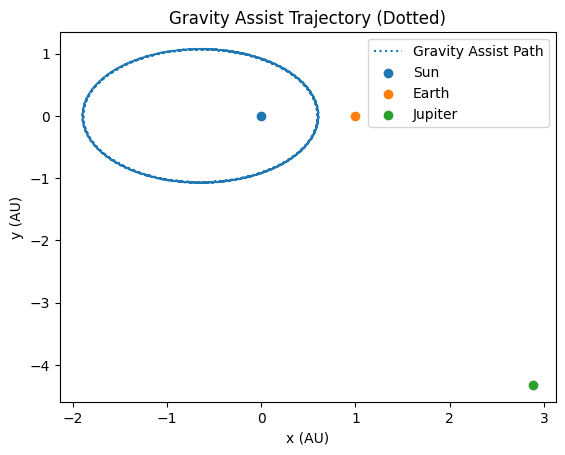

In [10]:
#plotting the trajectory again
plt.plot(x_vals, y_vals, linestyle='dotted', label="Gravity Assist Path")

# Plot Sun, Earth, Jupiter positions
plt.scatter(sim.particles[0].x, sim.particles[0].y, label="Sun")
plt.scatter(sim.particles[1].x, sim.particles[1].y, label="Earth")
plt.scatter(sim.particles[2].x, sim.particles[2].y, label="Jupiter")

plt.legend()
plt.title("Gravity Assist Trajectory (Dotted)")
plt.xlabel("x (AU)")
plt.ylabel("y (AU)")
plt.show()

In [11]:
# captured by earth or escape
def check_escape_or_capture(sim):
    earth = sim.particles[1]
    sc = sim.particles[3]
    
    dx = sc.x - earth.x
    dy = sc.y - earth.y
    distance = np.sqrt(dx**2 + dy**2)
    
    return distance

In [12]:
#track distance over the time 
sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

sim.add(m=1.0)
sim.add(m=3e-6, a=1.0)
sim.add(m=0.001, a=5.2)
sim.add(m=0, a=1.05, e=0.1)

sim.move_to_com()

times = np.linspace(0, 5, 300)
distances = []

for t in times:
    sim.integrate(t)
    distances.append(check_escape_or_capture(sim))

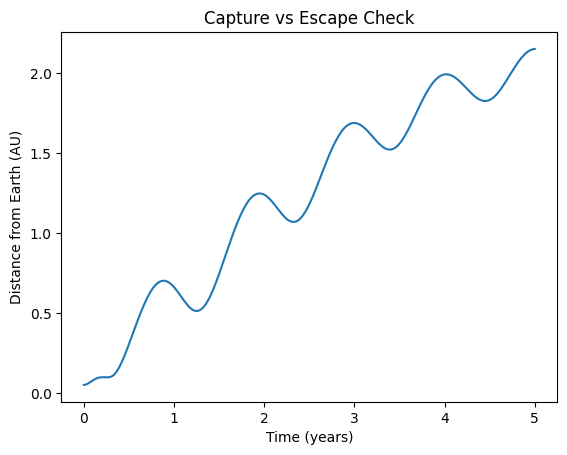

In [13]:
plt.plot(times, distances)
plt.xlabel("Time (years)")
plt.ylabel("Distance from Earth (AU)")
plt.title("Capture vs Escape Check")
plt.show()

In [14]:
import plotly.graph_objects as go

sim = rebound.Simulation()
sim.units = ('AU', 'yr', 'Msun')

# Sun, Earth, Jupiter
sim.add(m=1.0)
sim.add(m=3e-6, a=1.0)
sim.add(m=0.001, a=5.2)

# Spacecraft aimed for slingshot
sim.add(m=0, a=1.2, e=0.5)

sim.move_to_com()

times = np.linspace(0, 10, 300)

sun_x, sun_y = [], []
earth_x, earth_y = [], []
jup_x, jup_y = [], []
sc_x, sc_y = [], []

for t in times:
    sim.integrate(t)
    
    sun = sim.particles[0]
    earth = sim.particles[1]
    jupiter = sim.particles[2]
    sc = sim.particles[3]
    
    sun_x.append(sun.x); sun_y.append(sun.y)
    earth_x.append(earth.x); earth_y.append(earth.y)
    jup_x.append(jupiter.x); jup_y.append(jupiter.y)
    sc_x.append(sc.x); sc_y.append(sc.y)

In [15]:
frames = []

for i in range(len(times)):
    frame = go.Frame(
        data=[
            go.Scatter(x=[sun_x[i]], y=[sun_y[i]], mode='markers', name='Sun'),
            go.Scatter(x=[earth_x[i]], y=[earth_y[i]], mode='markers', name='Earth'),
            go.Scatter(x=[jup_x[i]], y=[jup_y[i]], mode='markers', name='Jupiter'),
            go.Scatter(x=[sc_x[i]], y=[sc_y[i]], mode='markers', name='Spacecraft'),
            go.Scatter(x=sc_x[:i], y=sc_y[:i], mode='lines', name='Path')
        ]
    )
    frames.append(frame)

In [16]:
fig = go.Figure(
    data=[
        go.Scatter(x=[sun_x[0]], y=[sun_y[0]], mode='markers', name='Sun'),
        go.Scatter(x=[earth_x[0]], y=[earth_y[0]], mode='markers', name='Earth'),
        go.Scatter(x=[jup_x[0]], y=[jup_y[0]], mode='markers', name='Jupiter'),
        go.Scatter(x=[sc_x[0]], y=[sc_y[0]], mode='markers', name='Spacecraft')
    ],
    frames=frames
)

fig.update_layout(
    title="Gravity Assist (Slingshot) Animation",
    xaxis=dict(range=[-6, 6]),
    yaxis=dict(range=[-6, 6]),
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play", "method": "animate", "args": [None]},
            {"label": "Pause", "method": "animate", "args": [[None], {"mode": "immediate"}]}
        ]
    }]
)

fig.show()
# Output is not visible in github webpage, refer to Folder/Output-Plotly

<p style="display: flex; justify-content: space-between;">
  <a href="../05-Applications/05-Black-Hole-Formation.ipynb" target="_blank">Previous</a>
  <a href="../06-More-Applications/02-Collision-and-Impact-Theory.ipynb" target="_blank">Next</a>
</p>

<img src="../Decorative-Elements/Section-Footer-Animated/Section-06-01.gif">